In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from tqdm import tqdm

In [23]:
character_df = pd.read_parquet("../data/pipeline/hathi_all/final/characters.parquet")
fashion_df = pd.read_parquet("../data/pipeline/hathi_all/final/fashion_mentions.parquet")

In [24]:
hathi_metadata = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")
hathi_metadata.loc[:, "book_id"] = hathi_metadata.docid.apply(lambda x: x + ".clean")
hathi_metadata = hathi_metadata.set_index("book_id")

/tmp/ipykernel_939793/3717131593.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  hathi_metadata = pd.read_csv("../data/hathimeta/titlemeta.tsv", sep="\t")


In [25]:
# merge fashion and character data

char_fashion = fashion_df.dropna(subset=["character_id"])
char_fashion.character_id = pd.to_numeric(char_fashion.character_id)
char_fashion = char_fashion.set_index(["book_id", "character_id"])


/tmp/ipykernel_939793/414876221.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  char_fashion.character_id = pd.to_numeric(char_fashion.character_id)


In [26]:
merged = char_fashion.merge(
    character_df.dropna(subset=["gender"]).set_index(["book_id", "character_id"]),
    how="inner",
    left_index=True, right_index=True,
    suffixes=("_fashion", "_char")
)

In [27]:
merged = merged.merge(hathi_metadata.inferreddate.dropna(), left_on="book_id", right_index=True)

In [28]:
merged.loc[:, "decade"] = merged.inferreddate // 10

In [29]:
merged.groupby("book_id").decade.first().value_counts()

decade
190.0    7670
191.0    6922
189.0    6415
188.0    3261
192.0    2615
187.0    2174
185.0    2075
186.0    1806
183.0    1678
184.0    1614
182.0    1268
181.0     481
180.0     410
198.0       1
Name: count, dtype: int64

In [66]:
print(merged.loc[("uva.x030576612.clean", 601)][lambda x: x.mention_id.eq(18529034)].sentence.iloc[0])

If you observe how this skirt is turned, and 
this sleeve ; a clumsy English rascal can do nothing like 
it.


/tmp/ipykernel_939793/1610148714.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  print(merged.loc[("uva.x030576612.clean", 601)][lambda x: x.mention_id.eq(18529034)].sentence.iloc[0])


In [93]:
fashion_df.head()

,book_id,mention_id,term,sentence,start_idx,end_idx,sentence_start_idx,sentence_end_idx,adjectives,character_id
0,chi.086202240.clean,17370773,shorts,How long I remained in shorts I cannot novembe...,23,29,4200,4409,[],110
1,chi.086202240.clean,17370773,shorts,How long I remained in shorts I cannot novembe...,23,29,4200,4409,[],111
2,chi.086202240.clean,17370773,shorts,How long I remained in shorts I cannot novembe...,23,29,4200,4409,[],0
3,chi.086202240.clean,17370777,stockings,"Tall, handsome, and retrousse, standing \nfive...",63,72,9610,9861,[],42
4,chi.086202240.clean,17370787,dress,Scattered around in pieces were the \ntorn fra...,63,68,20513,20664,[human],222


In [92]:
merged[merged.term.eq("skirt") & merged.decade.eq(181) & merged.gender.eq("he/him/his")]#["sentence"]

mention_id   term  \
book_id                  character_id                      
hvd.hxj2ez.clean         4728            17144952  skirt   
                         4808            17144952  skirt   
hvd.hxk4l9.clean         0               17381579  skirt   
mdp.39015039248037.clean 2397              695521  skirt   
mdp.39015059389596.clean 0                  33586  skirt   
...                                           ...    ...   
uva.x000673702.clean     2177            18177919  skirt   
                         0               18177919  skirt   
uva.x030576612.clean     0               18529034  skirt   
                         6729            18529252  skirt   
wu.89099432460.clean     150             16616028  skirt   

                                                                                sentence  \
book_id                  character_id                                                      
hvd.hxj2ez.clean         4728          And being further inter \nthen on, which were ...   
                         4808          And being further inter \nthen on, which were ...   
hvd.hxk4l9.clean         0             I twitched the \nskirt of my maid's gown repea...   
mdp.39015039248037.clean 2397          Ask him of the manners of the \npeople, and he...   
mdp.39015059389596.clean 0             For conceive me dressed in a long skirt \ned, ...   
...                                                                                  ...   
uva.x000673702.clean     2177          In the latter end of queen Anne's \nreign, and...   
                         0             In the latter end of queen Anne's \nreign, and...   
uva.x030576612.clean     0             If you observe how this skirt is turned, and \...   
                         6729          He overtook him just as Rockwood had laid \nho...   
wu.89099432460.clean     150           She was unable \nto answer the question; but a...   

                                       start_idx  end_idx  sentence_start_idx  \
book_id                  character_id                                           
hvd.hxj2ez.clean         4728                126      131             3612352   
                         4808                126      131             3612352   
hvd.hxk4l9.clean         0                    16       21                3329   
mdp.39015039248037.clean 2397                 70       75               66500   
mdp.39015059389596.clean 0                    34       39               19702   
...                                          ...      ...                 ...   
uva.x000673702.clean     2177                150      155              294514   
                         0                   150      155              294514   
uva.x030576612.clean     0                    24       29              221208   
                         6729                 55       60              496969   
wu.89099432460.clean     150                 106      111               96980   

                                       sentence_end_idx adjectives_fashion  \
book_id                  character_id                                        
hvd.hxj2ez.clean         4728                   3612484                 []   
                         4808                   3612484                 []   
hvd.hxk4l9.clean         0                         3493                 []   
mdp.39015039248037.clean 2397                     66652                 []   
mdp.39015059389596.clean 0                        19888             [long]   
...                                                 ...                ...   
uva.x000673702.clean     2177                    294671                 []   
                         0                       294671                 []   
uva.x030576612.clean     0                       221316                 []   
                         6729                    497085                 []   
wu.89099432460.clean     150                      97224                

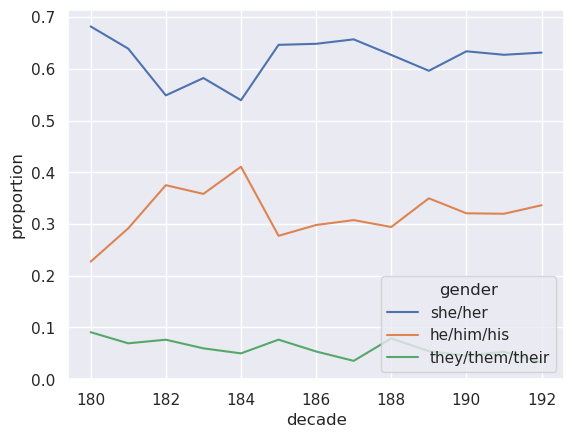

In [90]:
ax = sns.lineplot(
    data=merged.groupby(["decade", "term"]).gender.value_counts(normalize=True)[:, "muslin"].reset_index(),
    x="decade",
    y="proportion",
    hue="gender",
    
)
sns.move_legend(ax, "lower right")


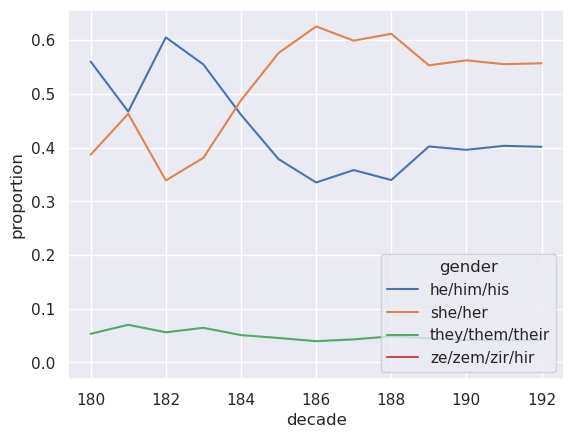

In [86]:
ax = sns.lineplot(
    data=merged.groupby(["decade", "term"]).gender.value_counts(normalize=True)[:, "bonnet"].reset_index(),
    x="decade",
    y="proportion",
    hue="gender",
    
)
sns.move_legend(ax, "lower right")


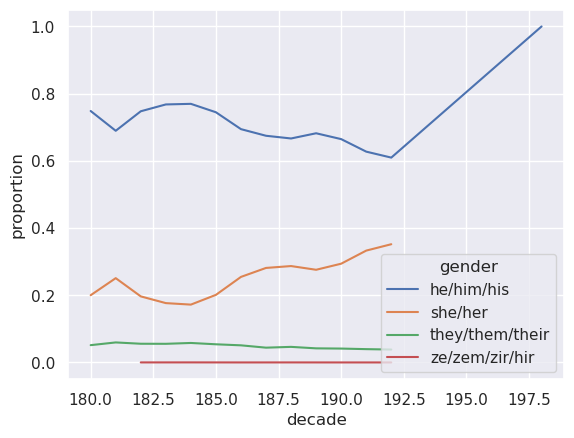

In [87]:
ax = sns.lineplot(
    data=merged.groupby(["decade", "term"]).gender.value_counts(normalize=True)[:, "hat"].reset_index(),
    x="decade",
    y="proportion",
    hue="gender",
    
)
sns.move_legend(ax, "lower right")


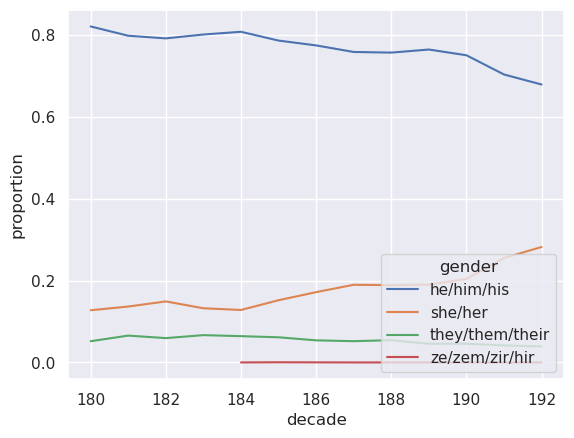

In [85]:
ax = sns.lineplot(
    data=merged.groupby(["decade", "term"]).gender.value_counts(normalize=True)[:, "coat"].reset_index(),
    x="decade",
    y="proportion",
    hue="gender",
    
)
sns.move_legend(ax, "lower right")


In [18]:
merged.groupby(["decade", "term"]).gender.value_counts(normalize=True)[:, "coat"]

decade  gender         
180.0   he/him/his         0.604651
        she/her            0.246124
        they/them/their    0.149225
181.0   he/him/his         0.600358
        she/her            0.246953
        they/them/their    0.152688
182.0   he/him/his         0.603152
        she/her            0.260456
        they/them/their    0.136392
183.0   he/him/his         0.591019
        she/her            0.257283
        they/them/their    0.151698
184.0   he/him/his         0.585133
        she/her            0.256709
        they/them/their    0.158159
185.0   he/him/his         0.589105
        she/her            0.260999
        they/them/their    0.149895
186.0   he/him/his         0.578480
        she/her            0.271592
        they/them/their    0.149927
187.0   he/him/his         0.580096
        she/her            0.272094
        they/them/their    0.147810
188.0   he/him/his         0.585339
        she/her            0.274856
        they/them/their    0.139805
189.

In [267]:
merged.groupby("decade").gender.value_counts(normalize=True)

decade  gender         
180.0   he/him/his         0.593431
        she/her            0.276630
        they/them/their    0.129939
181.0   he/him/his         0.587038
        she/her            0.275438
        they/them/their    0.137524
182.0   he/him/his         0.587377
        she/her            0.273288
        they/them/their    0.139334
183.0   he/him/his         0.579358
        she/her            0.259998
        they/them/their    0.160645
184.0   he/him/his         0.571852
        she/her            0.258960
        they/them/their    0.169188
185.0   he/him/his         0.569400
        she/her            0.277893
        they/them/their    0.152707
186.0   he/him/his         0.569400
        she/her            0.284818
        they/them/their    0.145782
187.0   he/him/his         0.566530
        she/her            0.289949
        they/them/their    0.143521
188.0   he/him/his         0.569734
        she/her            0.289495
        they/them/their    0.140771
189.

In [47]:
# construct vocab and indices

genders = []
features = []
decades = []

# keep only he/him and she/her (not they/them, which tends to be noisy in our data)
for row in tqdm(merged.itertuples(), total=len(merged)):
    if row.gender[0] in ("t", "z"):
        continue
    adjs = [adj for adj in row.adjectives_fashion if adj is not None]
    if len(adjs) == 0:
        continue
    decades.append(row.decade)
    genders.append(row.gender)
    row_feats = [f"term_{row.term.lower()}"]
    # row_feats += [adj.lower() for adj in adjs]
    # row_feats += [f"adj_{adj} {row.term}".lower() for adj in adjs]
    features.append(row_feats)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9475534/9475534 [00:17<00:00, 532605.67it/s]


In [48]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

encoder = CountVectorizer(
    input="content",
    lowercase=False,
    preprocessor=None,
    tokenizer=lambda x: x,
    min_df=100
)
encoder.fit(features)

le = LabelEncoder()
le.fit(genders)

def get_features(split):
    split_g = []
    split_f = []
    for i in split:
        split_g.append(genders[i])
        split_f.append(features[i])
    return split_g, split_f

def train_classifier(split):
    genders, features = get_features(split)
    X = encoder.transform(features)
    y = le.transform(genders)
    model = LogisticRegression(penalty="l1", solver="liblinear")
    model.fit(X, y)

    print(f1_score(y[:1000], model.predict(X[:1000])))

    # print(model.score(X[:1000], y[:1000]))
    return model

/data/naitian/fashion/.pixi/envs/default/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [49]:
len(genders), len(features), len(decades)

(2418869, 2418869, 2418869)

In [50]:
models = []
for decade in range(180, 192):
    print(decade)
    split = np.where(np.array(decades) == decade)[0]
    model = train_classifier(split)
    models.append(model)

180
0.24152542372881355
181
0.2874251497005988
182
0.0975609756097561
183
0.06153846153846154
184
0.2127659574468085
185
0.5227882037533512
186
0.47151898734177217
187
0.5957894736842105
188
0.4830508474576271
189
0.5301204819277109
190
0.5660377358490566
191
0.544766708701135


In [51]:
le.classes_

array(['he/him/his', 'she/her'], dtype='<U10')

In [52]:
def _():
    for i, decade in enumerate(range(180, 192)):
        print("======", decade, "=======")
        model = models[i]
        features = encoder.get_feature_names_out()
        k = 10
        
        print("she/her")
        for i in model.coef_.argsort()[0, -k:][::-1]:
            print(f"{features[i]}\t{model.coef_[0, i]}")
        
        print()
        
        print("he/him")
        for i in model.coef_.argsort()[0, :k]:
            print(f"{features[i]}\t{model.coef_[0, i]}")

_()

====== 180 =======
she/her
term_stays	2.623273009153843
term_cotton	2.400129457900548
term_laces	2.112447385996993
term_frocks	2.112447385996993
term_band	2.1124473859969926
term_coronet	1.8247653135452124
term_veils	1.7069822775842645
term_wear	1.7069725894184644
term_pelisse	1.5246510329290897
term_mantles	1.4192905172712647

he/him
term_belt	-2.0772073560294277
term_thong	-1.9306038810152988
term_greatcoat	-1.6252222314945646
term_pocket	-1.3375498480003836
term_uniform	-1.2719428766037155
term_waistcoat	-1.1006977634452746
term_trousers	-1.0656064436402604
term_coat	-1.0408779115751619
term_pockets	-1.001077611379165
term_boot	-0.9320847398922144
====== 181 =======
she/her
term_white	1.9512987135289193
term_slip	1.6999842852480136
term_muslin	1.699984284544812
term_stripe	1.5458336054207547
term_veils	1.5458336054207544
term_headgear	1.5458336054207544
term_stomacher	1.5458336048348056
term_stays	1.4404730897629299
term_sack	1.3635120481873897
term_shawls	1.3634762293049343

he/him